In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"C:\Users\rishi\Downloads\WorldSustainabilityDataset.csv")
df.head()

,Country Name,Country Code,Year,Access to electricity (% of population) - EG.ELC.ACCS.ZS,Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG,"Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS",Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS,Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS,Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS,Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS,...,Gini index (World Bank estimate) - SI.POV.GINI,Income Classification (World Bank Definition),Individuals using the Internet (% of population) - IT.NET.USER.ZS,"Life expectancy at birth, total (years) - SP.DYN.LE00.IN","Population, total - SP.POP.TOTL",Regime Type (RoW Measure Definition),Rural population (% of total population) - SP.RUR.TOTL.ZS,Total natural resources rents (% of GDP) - NY.GDP.TOTL.RT.ZS,Urban population (% of total population) - SP.URB.TOTL.IN.ZS,World Regions (UN SDG Definition)
0,Aruba,ABW,2000,91.660398,NaN,15.392211,2.389134,0.000190,0.000190,NaN,...,NaN,High income,NaN,NaN,NaN,NaN,53.283,NaN,NaN,Latin America and Caribbean
1,Aruba,ABW,2001,100.000000,NaN,11.491930,2.509046,0.000214,0.000214,NaN,...,NaN,High income,17.1,73.853,92892.0,NaN,53.661,0.000712,46.339,Latin America and Caribbean
2,Aruba,ABW,2002,100.000000,NaN,3.893620,2.721385,0.000223,0.000223,NaN,...,NaN,High income,18.8,73.937,94992.0,NaN,54.028,0.000657,45.972,Latin America and Caribbean
3,Aruba,ABW,2003,100.000000,NaN,6.713863,2.733676,0.000243,0.000243,NaN,...,NaN,High income,20.8,74.038,97016.0,NaN,54.394,0.000700,45.606,Latin America and Caribbean
4,Aruba,ABW,2004,100.000000,NaN,9.801576,2.678363,0.000256,0.000256,NaN,...,NaN,High income,23.0,74.156,98744.0,NaN,54.760,0.000685,45.240,Latin America and Caribbean


## Dataset Overview

The dataset contains sustainability indicators collected from different countries over multiple years.

Each row represents one country in a specific year.

The dataset contains economic, environmental, educational, health, technological, and social indicators which can be used to study sustainable development.

In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 54 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Country Name                                                                                  3287 non-null   object 
 1   Country Code                                                                                  3287 non-null   object 
 2   Year                                                                                          3287 non-null   int64  
 3   Access to electricity (% of population) - EG.ELC.ACCS.ZS                                      3193 non-null   float64
 4   Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG              2566 non-null   float64
 5   Adjusted net savings, exclu

Country Name                                                                                       0
Country Code                                                                                       0
Year                                                                                               0
Access to electricity (% of population) - EG.ELC.ACCS.ZS                                          94
Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG                 721
Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS       659
Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS                            67
Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS                     193
Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS                            176
Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS               

## Relationships Between Important Features

1. **GDP per Capita ↔ Life Expectancy**
   - Countries with higher GDP per capita generally have higher life expectancy due to better healthcare, nutrition, and living standards.

2. **GDP ↔ CO₂ Emissions**
   - Higher economic activity often leads to increased energy consumption and higher carbon dioxide emissions.

3. **Renewable Energy Consumption ↔ CO₂ Emissions**
   - Countries with greater use of renewable energy generally produce lower CO₂ emissions, indicating a cleaner energy mix.

4. **Access to Electricity ↔ Internet Usage**
   - Regions with better electricity access usually have higher internet usage because digital infrastructure depends on reliable power.

5. **Population ↔ Total GDP**
   - Countries with larger populations often have higher total GDP, although GDP per capita may vary significantly.

6. **Urban Population ↔ Energy Consumption**
   - Higher urbanization is generally associated with increased energy demand due to industrialization and infrastructure development.

7. **Education Indicators ↔ Employment Rate**
   - Higher education levels are generally linked with better employment opportunities and higher workforce participation.

8. **Income Classification ↔ Human Development Indicators**
   - High-income countries typically have better health, education, electricity access, and internet connectivity than low-income countries.

9. **Trade (Exports and Imports) ↔ Economic Growth**
   - Countries with higher trade activity often experience stronger economic growth and greater global economic integration.

10. **Forest Area ↔ Environmental Sustainability**
    - Countries with larger forest areas generally contribute more to carbon absorption and biodiversity conservation, supporting environmental sustainability.

## General Analysis

- The dataset contains multiple sustainability indicators.
- There are numerical and categorical variables.
- Several columns contain missing values.
- GDP, Population and CO₂ emission indicators are expected to be positively related.
- Renewable energy consumption may reduce carbon emissions.
- Internet usage and electricity access usually increase together.
- Higher GDP per capita generally leads to higher life expectancy.

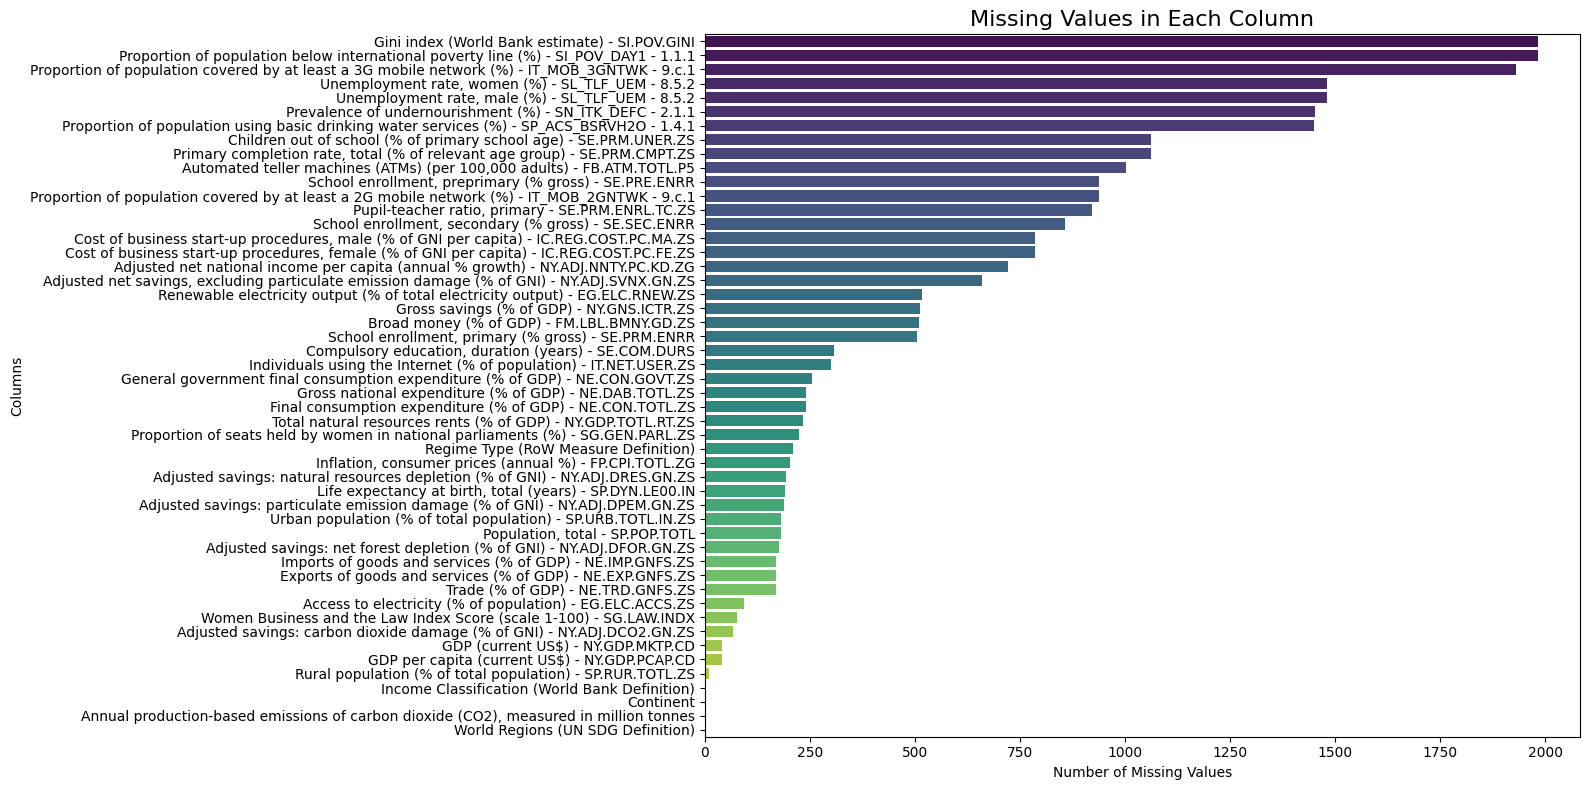

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count missing values
missing = df.isnull().sum()

# Keep only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(16,8))

sns.barplot(
    x=missing.values,
    y=missing.index,
    palette="viridis"
)

plt.title("Missing Values in Each Column", fontsize=16)
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()
plt.show()

## Handling Missing Values

Median is used for numerical columns because many sustainability indicators contain extreme values.

Mode is used for categorical columns because it preserves the most frequent category.

In [5]:
num_cols = df.select_dtypes(include='number').columns.drop('Year')

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

df.isnull().sum()

Country Name                                                                                    0
Country Code                                                                                    0
Year                                                                                            0
Access to electricity (% of population) - EG.ELC.ACCS.ZS                                        0
Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG                0
Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS      0
Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS                          0
Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS                    0
Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS                           0
Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS                    0
Automated teller mac

## Feature Engineering

A new feature called Trade Balance is created using exports and imports.

This helps understand whether a country exports more than it imports.

In [6]:
df["Trade Balance"] = (
    df["Exports of goods and services (% of GDP) - NE.EXP.GNFS.ZS"]
    -
    df["Imports of goods and services (% of GDP) - NE.IMP.GNFS.ZS"]
)

C:\Users\rishi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


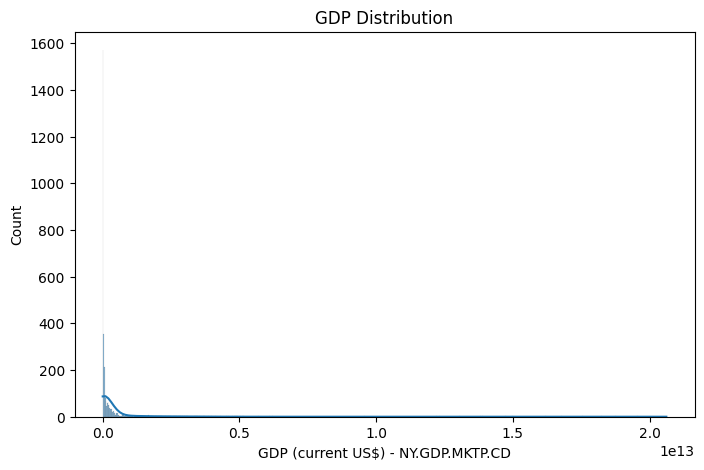

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["GDP (current US$) - NY.GDP.MKTP.CD"],
    kde=True
)

plt.title("GDP Distribution")
plt.show()

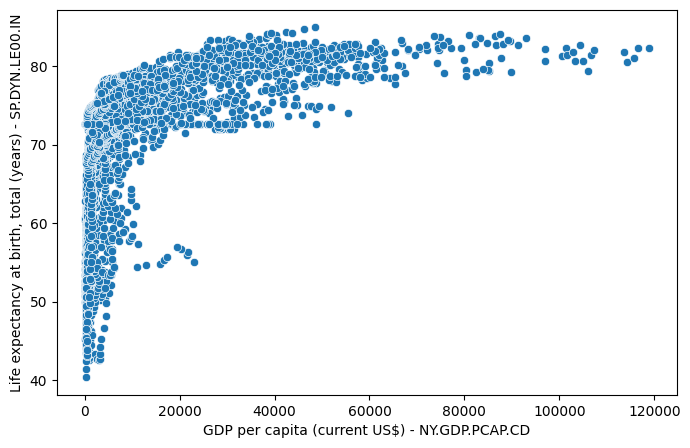

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="GDP per capita (current US$) - NY.GDP.PCAP.CD",
    y="Life expectancy at birth, total (years) - SP.DYN.LE00.IN"
)

plt.show()

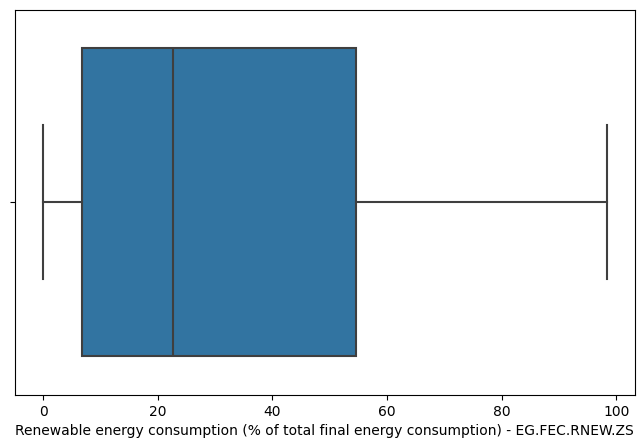

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Renewable energy consumption (% of total final energy consumption) - EG.FEC.RNEW.ZS"]
)

plt.show()

## Encoding Categorical Variables

One-Hot Encoding is used because categorical variables have no natural ordering.

This prevents introducing false numerical relationships.

In [10]:
print(df.columns)

Index(['Country Name', 'Country Code', 'Year',
       'Access to electricity (% of population) - EG.ELC.ACCS.ZS',
       'Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG',
       'Adjusted net savings, excluding particulate emission damage (% of GNI) - NY.ADJ.SVNX.GN.ZS',
       'Adjusted savings: carbon dioxide damage (% of GNI) - NY.ADJ.DCO2.GN.ZS',
       'Adjusted savings: natural resources depletion (% of GNI) - NY.ADJ.DRES.GN.ZS',
       'Adjusted savings: net forest depletion (% of GNI) - NY.ADJ.DFOR.GN.ZS',
       'Adjusted savings: particulate emission damage (% of GNI) - NY.ADJ.DPEM.GN.ZS',
       'Automated teller machines (ATMs) (per 100,000 adults) - FB.ATM.TOTL.P5',
       'Broad money (% of GDP) - FM.LBL.BMNY.GD.ZS',
       'Children out of school (% of primary school age) - SE.PRM.UNER.ZS',
       'Compulsory education, duration (years) - SE.COM.DURS',
       'Cost of business start-up procedures, female (% of GNI per capita) - IC.REG.CO

In [11]:
df = pd.get_dummies(df,
                    columns=cat_cols,
                    drop_first=True)

In [12]:
print(df.describe)
df.shape

<bound method NDFrame.describe of       Year  Access to electricity (% of population) - EG.ELC.ACCS.ZS  \
0     2000                                          91.660398          
1     2001                                         100.000000          
2     2002                                         100.000000          
3     2003                                         100.000000          
4     2004                                         100.000000          
...    ...                                                ...          
3282  2014                                          32.300000          
3283  2015                                          33.700000          
3284  2016                                          39.676228          
3285  2017                                          40.144283          
3286  2018                                          40.616360          

      Adjusted net national income per capita (annual % growth) - NY.ADJ.NNTY.PC.KD.ZG  \
0          

(3287, 410)

## Feature Scaling

StandardScaler is applied to numerical variables so that all features have a similar scale.

Scaling improves the performance of many machine learning algorithms.

In [13]:
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [14]:
df.shape

(3287, 410)

# Final Insights

1. GDP per capita has a positive relationship with life expectancy.

2. Countries with better electricity access generally have higher internet usage.

3. Renewable energy consumption varies significantly among countries.

4. Several sustainability indicators contained missing values, making preprocessing essential.

5. Median imputation was chosen for numerical columns because it is robust to outliers.

6. One-Hot Encoding was used to avoid assigning artificial numerical order to categorical variables.

7. StandardScaler normalized numerical features, making them suitable for machine learning models.

8. Feature engineering (Trade Balance) provides additional information about a country's economic sustainability.